**1. Import Library**

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

df = pd.read_csv('Crop_recommendation.csv')

2. Load Dataset iris dari Python

In [2]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

2.1 Dataset Crop Recommendation

Memprediksi jenis tanaman yang cocok ditanam berdasarkan kondisi tanah dan lingkungan.

In [17]:
df = pd.read_csv('Crop_recommendation.csv')

| Fitur       | Keterangan       |
| ----------- | ---------------- |
| N           | Nitrogen tanah   |
| P           | Phosphorus tanah |
| K           | Kalium tanah     |
| Temperature | Suhu             |
| Humidity    | Kelembaban       |
| pH          | Keasaman tanah   |
| Rainfall    | Curah hujan      |


In [18]:

df.info()
#Jumlah tanaman:
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

**3. Membuat DataFrame**

In [3]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**4. Melihat Nama Kelas**

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

**5. Pisahkan Feature dan Label**

In [5]:
X = iris.data
y = iris.target

5.1 Pisahkan Feature dan Target

In [19]:
X = df[
[
'N',
'P',
'K',
'temperature',
'humidity',
'ph',
'rainfall'
]
]

y = df['label']

**6. Membagi Data Training dan Testing**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**7. Normalisasi Data**

In [21]:
scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)

**8. Membuat Model KNN**

In [22]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

**9. Training Model**

In [23]:
knn.fit(
    X_train,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


**10. Prediksi Data Testing**

In [24]:
y_pred = knn.predict(
    X_test
)

In [61]:
y_pred

array(['muskmelon', 'watermelon', 'papaya', 'papaya', 'apple', 'mango',
       'apple', 'mothbeans', 'mungbean', 'lentil', 'blackgram', 'coconut',
       'pomegranate', 'jute', 'coconut', 'pomegranate', 'apple', 'cotton',
       'papaya', 'muskmelon', 'coffee', 'papaya', 'orange', 'papaya',
       'chickpea', 'jute', 'mungbean', 'orange', 'pigeonpeas', 'jute',
       'pomegranate', 'lentil', 'jute', 'lentil', 'jute', 'blackgram',
       'jute', 'chickpea', 'chickpea', 'kidneybeans', 'papaya', 'mango',
       'blackgram', 'maize', 'mungbean', 'maize', 'pigeonpeas', 'coconut',
       'muskmelon', 'maize', 'blackgram', 'coffee', 'grapes', 'mungbean',
       'coffee', 'kidneybeans', 'cotton', 'apple', 'banana', 'lentil',
       'watermelon', 'coconut', 'lentil', 'orange', 'papaya', 'lentil',
       'orange', 'rice', 'muskmelon', 'pigeonpeas', 'muskmelon',
       'coconut', 'jute', 'banana', 'blackgram', 'papaya', 'banana',
       'cotton', 'watermelon', 'orange', 'coffee', 'chickpea', 'ric

**11. Evaluasi Model**

Accuracy

In [25]:
accuracy_score(
    y_test,
    y_pred
)

0.9568181818181818

Classification Report

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

ValueError: Number of classes, 22, does not match size of target_names, 3. Try specifying the labels parameter

Classification Report untuk crop recom

In [27]:
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      1.00      0.94        17
      grapes       1.00      1.00      1.00        14
        jute       0.81      0.96      0.88        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.69      1.00      0.81        11
       maize       1.00      0.90      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.83      0.91        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

Confusion Matrix

In [28]:
confusion_matrix(
    y_test,
    y_pred
)

array([[23,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0, 21,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0, 19,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 26,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 14,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0, 22,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,

**12. Prediksi Data Baru**

In [13]:
data_baru = [
    [
        5.1,  # sepal length
        3.5,  # sepal width
        1.4,  # petal length
        0.2   # petal width
    ]
]

In [14]:
# Normalisasi:
data_baru = scaler.transform(
    data_baru
)

In [15]:
# Prediksi:
hasil = knn.predict(
    data_baru
)


hasil

array([0])

In [16]:
iris.target_names[0]

'setosa'

In [29]:
# tanah_baru = [
# [
# 90,    # Nitrogen
# 40,    # Phosphorus
# 40,    # Kalium
# 25,    # Temperature
# 80,    # Humidity
# 6.5,   # pH
# 200    # Rainfall
# ]
# ]


tanah_baru = [
[
90,     # Nitrogen (N)
42,     # Phosphorus (P)
43,     # Kalium (K)
20.8,   # Temperature
82,     # Humidity
6.5,    # pH
202     # Rainfall
]
]

In [30]:
tanah_baru = scaler.transform(
    tanah_baru
)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
hasil = knn.predict(
    tanah_baru
)


print(
"Tanaman yang cocok:",
hasil[0]
)

Tanaman yang cocok: rice


**13. Mencari K Terbaik (Hyperparameter Tuning Sederhana)**

In [32]:
akurasi = []


for k in range(1,20):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )


    pred = model.predict(
        X_test
    )


    acc = accuracy_score(
        y_test,
        pred
    )

    akurasi.append(acc)

Visualisasi:

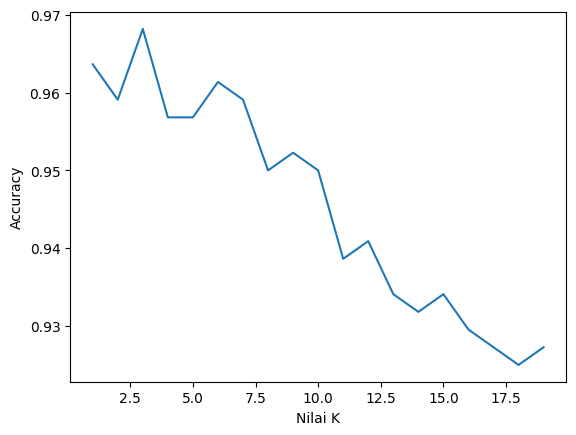

In [33]:
plt.plot(
    range(1,20),
    akurasi
)

plt.xlabel("Nilai K")
plt.ylabel("Accuracy")

plt.show()